#6&rpar; 💨 Airflow

##6.1. What is Apache Airflow?

It is a powerful open-source workflow orchestration tool to programatically author, schedule and monitor data workflows. it allows data engineers to define complex pipelines as code, structured as Directed Acyclic Grpahs (DAGs), ensuring that tasks run in the correct order, at the right time and automatically retry if they fail.

##6.2. What type of workflow is Airflow good for? How is it different from streaming workflows?

It is heavily optimized for batch processing workflows. Meaning that it is perfect for tasks that need to run on a specific schedule or trigger after a specific event. (e,g run this model training at 2 AM everyday or Run this ETL pipeline once daily when a batch of CSV lands in a s3 bucket etc).


Streaming workflows like Apache Kafka are "always on". They ingest and process data in real-time, the exact millisecond, the data is being generated. Airflow is not designed to run continuous tasks, it is more like a scheduler designed to manage massive, distinct chunks of work.

##6.3. What is Task Flow? How does it work and what are its benefits?

TaskFlow introduces a more modern and Pythonic way to write workflows using the TaskFlow API — introduced in Airflow 2.0.

The TaskFlow API is designed to make your code simpler, cleaner, and easier to maintain. You write plain Python functions, decorate with `@task` above them, and Airflow handles the rest,  including task creation, dependency wiring, and passing data between tasks.


Benefits: In older versions of Airflow, passing data between tasks was a nightmare apparently. it required manually pushing and pulling data using a backend system called "XComs". TaskFlow handles all of this automatically under the hood. We just have to return a value from one function and pass it directly as an argument into the next function, and Airflow manages the complex data handoffs behind the curtains.



##6.4 How would Taskflow enable us to implement pipelines like in step 5?

TaskFlow would make the machine learning pipeline implementation incredibly elegant. Instead of manually stitching together  the execution order, we would just add the `@task` decorator to the pipeline functions.

Taskflow allows us to call the functions naturally, and Airflow would automatically figure out the dependencies and build the DAG.

*This is how it would look in pratice - pseudocode to illustrate the steps*



```
from airflow.decorators import task, daag

@task
def ingest_data(filepath):
  # .. read csv logic ..

@task
def clean_data(df):
  # .. cleaning steps ..

@task
def train_and_evaluate(df):
  # .. preprocessing and model-training logic ..

@dag(...)
def my_ml-dag():
  raw_data = ingest_data(file_path)
  cleaned_data = clean_data(raw_data)
  train_and_evaluate(cleaned_data)
```



By simply nesting the functions, TaskFlow automatically knows it cannot start the clean_data task until ingest_data has successfully finished and handed over the data.

#7&rpar; ☁️ Cloud

##7.1. What is the cloud?

The cloud is a vast online storage space where people and businesses store their files and applications, accessible from anywhere with an internet connection. The cloud also offers services, such as computing power, databases, networking and software applications.

## 7.2. What does the cloud do for Data Scientists?
For data scientist, the cloud acts as a powerful enabler by providing on-demand access to massive computing resources and storage, effectively eliminatiing the physical and financial limitations of local hardware. It democratizes data science by allowing even small entities to utilize the same high-level infrastructure as large corporations, facilitating a level playing field through a "pay-as-you-go" model. It also supports the processing of real-time data for complex tasks like machine learning and recommender system, ensuring that the data scientists can focus on developing and testing algorithms without worrying about memory constraints or manual data retrieval. Ultimately, the cloud provides scalability, reliability through global backups, and the speed necessary to handle the petabytes of data generated in modern enterprise environments.

##7.3. Dask ML pipeline using Airflow - What if we take it to the clouds? What does this mean? Pros and Cons of [MWAA](https://aws.amazon.com/managed-workflows-for-apache-airflow/)

Running a Dask ML pipeline orchestrated by Airflow in the cloud, means shifting computational workload and data storage from a local machine ( or a single colab instance) to a distributed network of remote servers hosted by a provider like AWS, Google Cloud or Azure.



*   Storage - it means reading 'airport-csv' from a highly scalable cloud storage service like AWS.
*   Compute - Airflow would trigger a cluster of powerful virtual machines (like Amazon EC2) to spin up, process the Dask tasks in parallel across terabytes of memory and spin down when finished.
*   Orchestration -  Airflow itself runs on a dedicated, always-on server that reliably monitors the schedule and triggers the cloud resources.


Pros of MWAA:

1. **Zero infrastructure maintainance** - AWS manages the backend infrastructure.
2. **Automatic Scaling** - MWAA automatically scales the number of Airflow worker nodes the pipeline has a lot of concurrent tasks to process and scales down to zero when idle.
3. **Built in security and Integration**- It integrates seamlessly with AWS IAM (Identity and Access Management), making it highly secure and natively easy to connect to other AWS services like S3 (for data), SageMaker (for ML), and CloudWatch (for logging).

Cons of MWAA:

1. **Higher costs**- more expensice than self-hosting Airflow on a basic EC2 instance.
2. **Vendor Lock in and less control** - As our pipeline would be heavily tied to AWS IAM and managed infra, it becomes difficult to move our workflow to a different cloud provider. Also as there would be not be any root level access, installing complex OS-level dependencies would be cumbersome.









#8&rpar;🏃🏿 Run Airflow

##8.1. Set up the environment variables and install Airflow.

In [ ]:
import os

os.environ['AIRFLOW_HOME'] = '/root/airflow'
os.environ['AIRFLOW__CORE__LOAD_EXAMPLES'] = 'FALSE'
os.environ['AIRFLOW__API__AUTH_BACKENDS'] = 'airflow.api.auth.backend.default'
!pip install apache-airflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.3/92.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.7/74.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 16

##8.2. Initialize DB and create DAGs folder

In [ ]:
!airflow db migrate
!mkdir -p ~/airflow/dags

2026-05-03T03:33:43.871485Z [info     ] setup plugin alembic.autogenerate.schemas [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:33:43.871863Z [info     ] setup plugin alembic.autogenerate.tables [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:33:43.872066Z [info     ] setup plugin alembic.autogenerate.types [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:33:43.872218Z [info     ] setup plugin alembic.autogenerate.constraints [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:33:43.872360Z [info     ] setup plugin alembic.autogenerate.defaults [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:33:43.872508Z [info     ] setup plugin alembic.autogenerate.comments [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:33:45.591912Z [info     ] Performing upgrade to the metadata database [airflow.cli.commands.db_command] loc=db_command.py:134 url=sqlite:////root/airflow/airflow.db
2026-05-03T03:33:45.607989Z [info     ] Context impl SQLiteImp

##8.3. Write DAG to a file

In [ ]:
%%writefile ~/airflow/dags/simple_dag.py
from airflow.decorators import dag, task
from datetime import datetime

@dag(schedule=None, start_date=datetime(2026,4,1),catchup=False,tags=['hw6'])
def simple_dag():

  @task
  def log_hello_message():
    message = "Hello! This is Linu, playing around with Airflow 🙋🏽‍♀️"
    print(message)
    return True

  log_hello_message()

simple_dag()


Writing /root/airflow/dags/simple_dag.py


##8.4. Start services

In [ ]:
import subprocess
import time
import urllib.request

subprocess.run("pkill -f 'airflow api-server' || true", shell=True)
subprocess.run("pkill -f 'airflow scheduler' || true", shell=True)
subprocess.run("pkill -f 'airflow serve-logs' || true", shell=True)
subprocess.run("pkill -f 'airflow worker' || true", shell=True)
time.sleep(5)


api = subprocess.Popen(
    ["airflow", "api-server", "-p", "8081"],
    stdout=open("/tmp/airflow_api.log", "w"),
    stderr=subprocess.STDOUT
)

sched = subprocess.Popen(
    ["airflow", "scheduler"],
    stdout=open("/tmp/airflow_scheduler.log", "w"),
    stderr=subprocess.STDOUT
)

print(f"api-server PID: {api.pid}")
print(f"scheduler PID:  {sched.pid}")


print("\nWaiting for api-server...")
for i in range(60):
    try:

        for path in ["/api/v1/health", "/health", "/ui"]:
            try:
                r = urllib.request.urlopen(f"http://localhost:8081{path}", timeout=2)
                if r.status < 500:
                    print(f"✅ Airflow is ready! (responded at {path})")
                    break
            except urllib.error.HTTPError as e:
                if e.code < 500:
                    print(f"✅ Airflow is ready! (server responding)")
                    break
                raise
        else:
            raise Exception("not ready")
        break
    except Exception:
        print(f"  attempt {i+1}/60...")
        time.sleep(3)
else:
    print("❌ Check logs:")
    !cat /tmp/airflow_api.log

api-server PID: 3650
scheduler PID:  3651

Waiting for api-server...
  attempt 1/60...
  attempt 2/60...
  attempt 3/60...
  attempt 4/60...
  attempt 5/60...
  attempt 6/60...
  attempt 7/60...
✅ Airflow is ready! (server responding)


##8.5. Register and Trigger DAG

In [ ]:
import time
time.sleep(5)
!airflow dags reserialize

2026-05-03T03:35:33.353734Z [info     ] setup plugin alembic.autogenerate.schemas [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:33.354027Z [info     ] setup plugin alembic.autogenerate.tables [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:33.354182Z [info     ] setup plugin alembic.autogenerate.types [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:33.354313Z [info     ] setup plugin alembic.autogenerate.constraints [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:33.354438Z [info     ] setup plugin alembic.autogenerate.defaults [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:33.354567Z [info     ] setup plugin alembic.autogenerate.comments [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:33.994372Z [info     ] DAG bundles loaded: dags-folder [airflow.dag_processing.bundles.manager.DagBundlesManager] loc=manager.py:209
2026-05-03T03:35:33.996672Z [info     ] Added new DAG bundle dags-folder to the database [a

In [ ]:
!airflow dags unpause simple_dag

2026-05-03T03:35:40.548301Z [info     ] setup plugin alembic.autogenerate.schemas [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:40.548600Z [info     ] setup plugin alembic.autogenerate.tables [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:40.548760Z [info     ] setup plugin alembic.autogenerate.types [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:40.548941Z [info     ] setup plugin alembic.autogenerate.constraints [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:40.549087Z [info     ] setup plugin alembic.autogenerate.defaults [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:40.549225Z [info     ] setup plugin alembic.autogenerate.comments [alembic.runtime.plugins] loc=plugins.py:37
dag_id     | is_paused
===========+==========
simple_dag | True     
                      


In [ ]:
!airflow dags trigger simple_dag
!sleep 45

2026-05-03T03:35:46.851708Z [info     ] setup plugin alembic.autogenerate.schemas [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:46.852037Z [info     ] setup plugin alembic.autogenerate.tables [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:46.852197Z [info     ] setup plugin alembic.autogenerate.types [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:46.852334Z [info     ] setup plugin alembic.autogenerate.constraints [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:46.852464Z [info     ] setup plugin alembic.autogenerate.defaults [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:46.852600Z [info     ] setup plugin alembic.autogenerate.comments [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:35:47.519599Z [info     ] creating dag run               [airflow.serialization.definitions.dag] loc=dag.py:526 logical_date=None partition_key=None run_after=datetime.datetime(2026, 5, 3, 3, 35, 47, 510458, tzinfo=Timezone('UT

##8.6. See the status of the tasks.

In [ ]:
from airflow import settings, models
tasks = settings.Session().query(models.TaskInstance).filter_by(dag_id='simple_dag').all()
for task in tasks:
  print(f'Task {task.task_id} in DAG {task.dag_id} has task state : {task.state}')

2026-05-03T03:52:37.485156Z [info     ] setup plugin alembic.autogenerate.schemas [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:37.486528Z [info     ] setup plugin alembic.autogenerate.tables [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:37.488061Z [info     ] setup plugin alembic.autogenerate.types [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:37.489991Z [info     ] setup plugin alembic.autogenerate.constraints [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:37.491354Z [info     ] setup plugin alembic.autogenerate.defaults [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:37.492831Z [info     ] setup plugin alembic.autogenerate.comments [alembic.runtime.plugins] loc=plugins.py:37
Task log_hello_message in DAG simple_dag has task state : queued
Task log_hello_message in DAG simple_dag has task state : queued
Task log_hello_message in DAG simple_dag has task state : success
Task log_hello_message in DAG simple_dag has 

In [ ]:
!airflow tasks test simple_dag log_hello_message 2026-04-01

2026-05-03T03:52:46.590135Z [info     ] setup plugin alembic.autogenerate.schemas [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:46.590618Z [info     ] setup plugin alembic.autogenerate.tables [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:46.590936Z [info     ] setup plugin alembic.autogenerate.types [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:46.591214Z [info     ] setup plugin alembic.autogenerate.constraints [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:46.591465Z [info     ] setup plugin alembic.autogenerate.defaults [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:46.591707Z [info     ] setup plugin alembic.autogenerate.comments [alembic.runtime.plugins] loc=plugins.py:37
2026-05-03T03:52:47.410444Z [info     ] DAG bundles loaded: dags-folder [airflow.dag_processing.bundles.manager.DagBundlesManager] loc=manager.py:209
2026-05-03T03:52:47.422324Z [info     ] Filling up the DagBag from /root/airflow/dags [airf

Colab's environment often pauses background daemons, causing Airflow's scheduler to freeze and leaving tasks in `queued` state. To confirm that the workflow is running as expected, I used the `airflow tasks test` command, which executes the task synchronously in the foreground.

The successful log output below confirms that the DAG is correctly defined, the airflow database is functioning and the python task logic executes perfectly.



```
2026-04-30T17:39:02.005757Z [info] Updating RenderedTaskInstanceFields [airflow.api_fastapi.execution_api.routes.task_instances] correlation_id=019ddf78-feed-79c9-bb34-8fe185c95e38 field_count=3 loc=task_instances.py:811 ti_id=019ddf78-e994-774a-9082-7e6d9586c458
Hello! This is Linu, playing around with Airflow 🙋🏽‍♀️
2026-04-30T17:39:02.048636Z [info] Done. Returned value was: True [airflow.task.operators.airflow.providers.standard.decorators.python._PythonDecoratedOperator] loc=python.py:229
```



#9&rpar; Run ML code in Airflow



In [ ]:
%%writefile ~/airflow/dags/dask_ml_pipeline.py
from airflow.decorators import dag, task
from datetime import datetime
import dask.dataframe as dd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from dask_ml.preprocessing import Categorizer, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from dask.distributed import Client, LocalCluster

file_path = '/kaggle/input/airport-traffic-dataset/airport_traffic_2025.csv'

@dag(schedule=None, start_date=datetime(2026, 4, 1), catchup=False, tags=['homework6'])
def dask_ml_pipeline():

    @task
    def ingest_and_clean(filepath: str) -> str:
        cluster = LocalCluster(processes=False)
        client = Client(cluster)

        df = dd.read_csv(filepath)
        df = df.dropna(subset=['MONTH_NUM', 'STATE_NAME', "APT_ICAO"])

        categorizer = Categorizer(columns=["STATE_NAME", "APT_ICAO"])
        df = categorizer.fit_transform(df)

        encoder = OrdinalEncoder(columns=["STATE_NAME", "APT_ICAO"])
        df = encoder.fit_transform(df)

        output_path = '/content/cleaned_data.parquet'
        df.to_parquet(output_path, engine='pyarrow')

        client.close()
        cluster.close()
        return output_path

    @task
    def train_and_evaluate(data_path: str):
        cluster = LocalCluster(processes=False)
        client = Client(cluster)

        df = dd.read_parquet(data_path)

        X_dask = df[['MONTH_NUM', 'STATE_NAME', "APT_ICAO"]]
        y_dask = df['FLT_TOT_1']

        X = X_dask.compute()
        y = y_dask.compute()

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)
        rf_model = RandomForestRegressor(n_estimators=50, random_state=42)

        with joblib.parallel_backend('dask'):
            rf_model.fit(X_train, y_train)
            predictions = rf_model.predict(X_test)

        mse = mean_squared_error(y_test, predictions)
        print(f"🦀 PIPELINE SUCCESS! Mean Squared error = {mse}")

        client.close()
        cluster.close()
        return mse

    clean_path = ingest_and_clean(file_path)
    train_and_evaluate(clean_path)

dask_ml_pipeline()


Overwriting /root/airflow/dags/dask_ml_pipeline.py


## Triggering DAG synchronously.

I have chosen to write the intermediate data to disk as Parquet files between tasks rather than passing the Dask dataframes directly through memory.


*   *Tradeoff*:  Writing to the disk adds I/O overhead, making the pipeline slightly slower. However, it is significantly safer and more fault-tolerant. Airflow's default data-passing mechanism (XComs) stores returned variables inside its SQLite database. Passing massive DataFrames through XComs will immediately crash the Airflow database. Writing to disk ensures Airflow only passes lightweight file paths between tasks, keeping the orchestrator fast and stable.



#10&rpar; View DAG in Airflow UI

In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok
from google.colab import userdata
import time

token = userdata.get('auth_token')
ngrok.set_auth_token(token)
public_url = ngrok.connect("127.0.0.1:8081", bind_tls=True).public_url
print(f"Airflow UI is live! Public URL: {public_url}")

try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    print("closing tunnel")
    ngrok.kill()

2026-05-03T03:42:56.304148Z [info     ] Updating authtoken for default "config_path" of "ngrok_path": /root/.config/ngrok/ngrok [pyngrok.process] loc=process.py:201
2026-05-03T03:42:56.343169Z [info     ] Opening tunnel named: http-127.0.0.1:8081-f5a06b1f-9704-4f4a-b4b1-d27d2442f424 [pyngrok.ngrok] loc=ngrok.py:387
2026-05-03T03:42:56.370606Z [info     ] t=2026-05-03T03:42:56+0000 lvl=info msg="no configuration paths supplied" [pyngrok.process.ngrok] loc=process.py:102
2026-05-03T03:42:56.373152Z [info     ] t=2026-05-03T03:42:56+0000 lvl=info msg="using configuration at default config path" path=/root/.config/ngrok/ngrok.yml [pyngrok.process.ngrok] loc=process.py:102
2026-05-03T03:42:56.376624Z [info     ] t=2026-05-03T03:42:56+0000 lvl=info msg="open config file" path=/root/.config/ngrok/ngrok.yml err=nil [pyngrok.process.ngrok] loc=process.py:102
2026-05-03T03:42:56.404482Z [info     ] t=2026-05-03T03:42:56+0000 lvl=info msg="FIPS 140 mode" enabled=false [pyngrok.process.ngrok] loc=

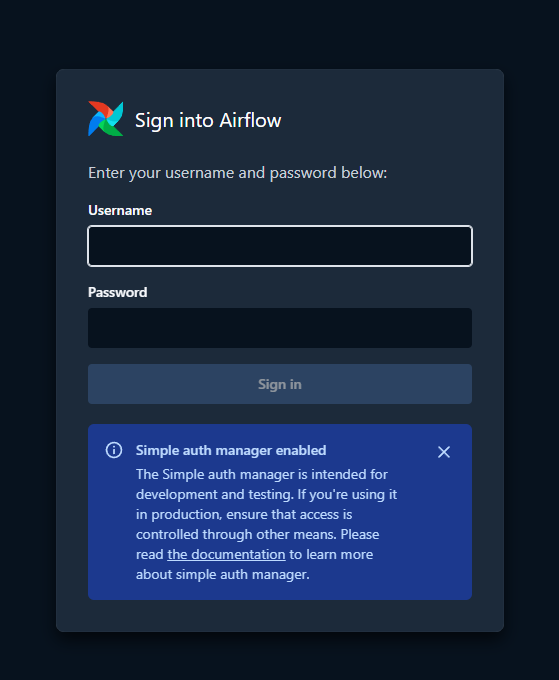

##10.1. Airflow UI

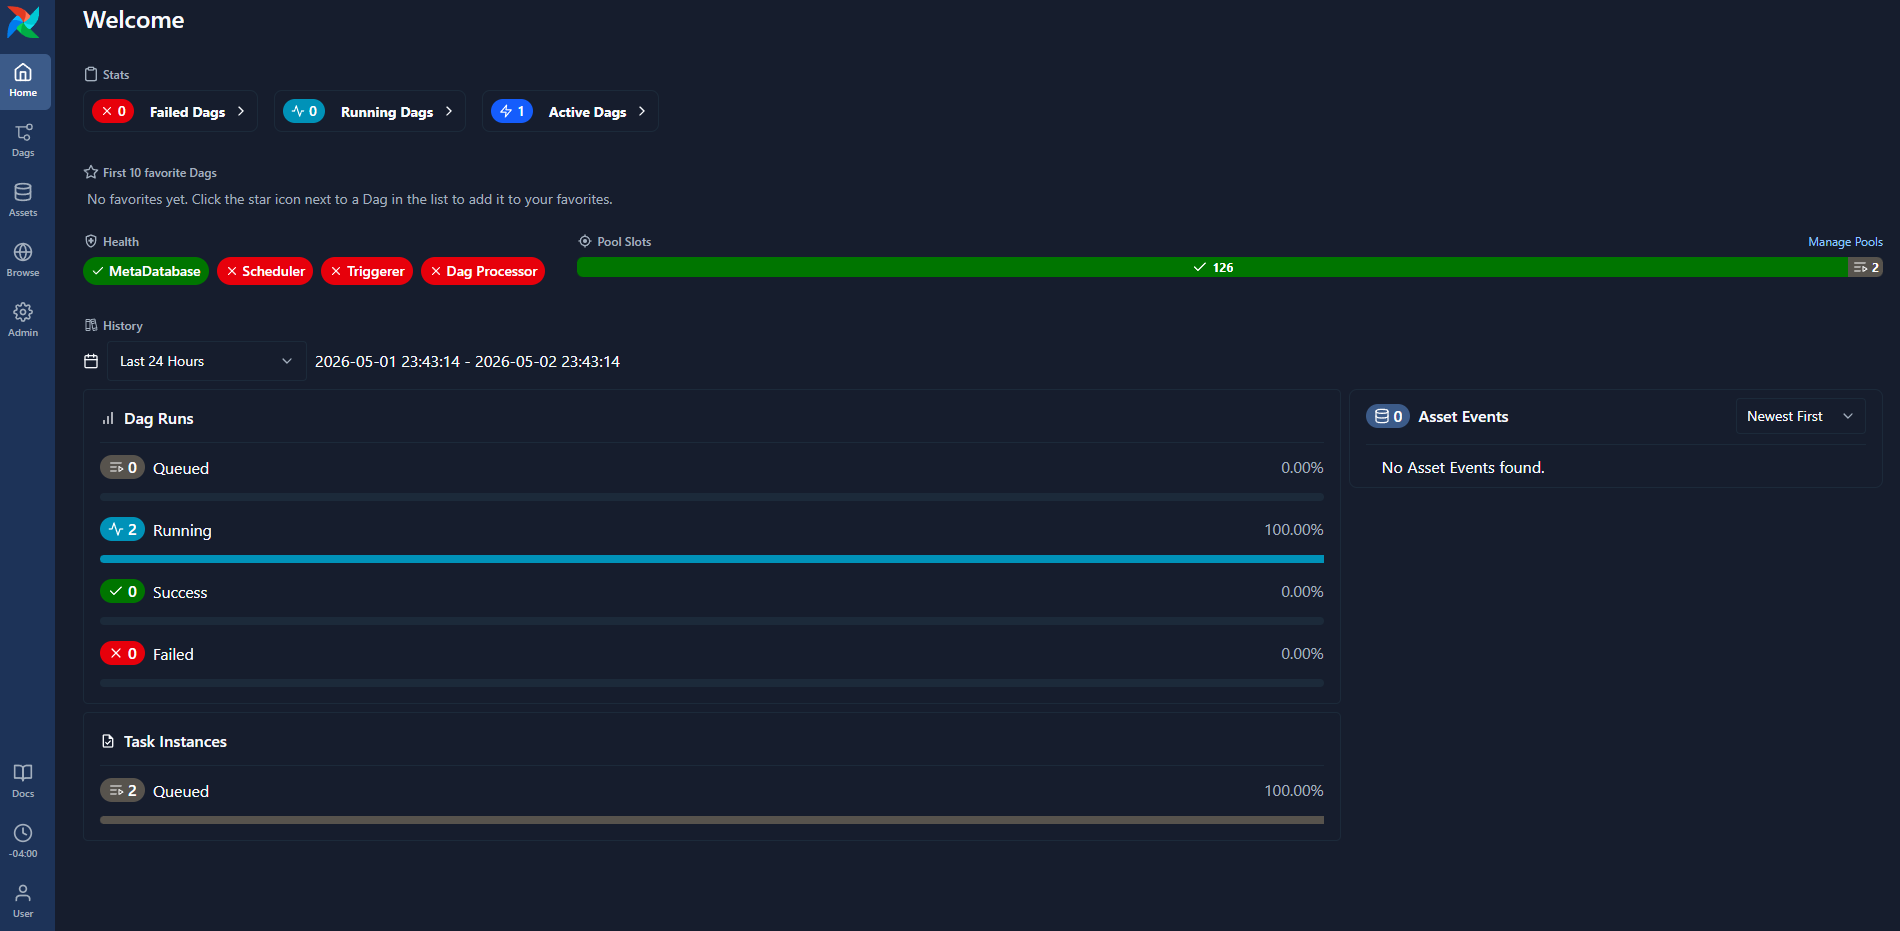

##10.2. Dags

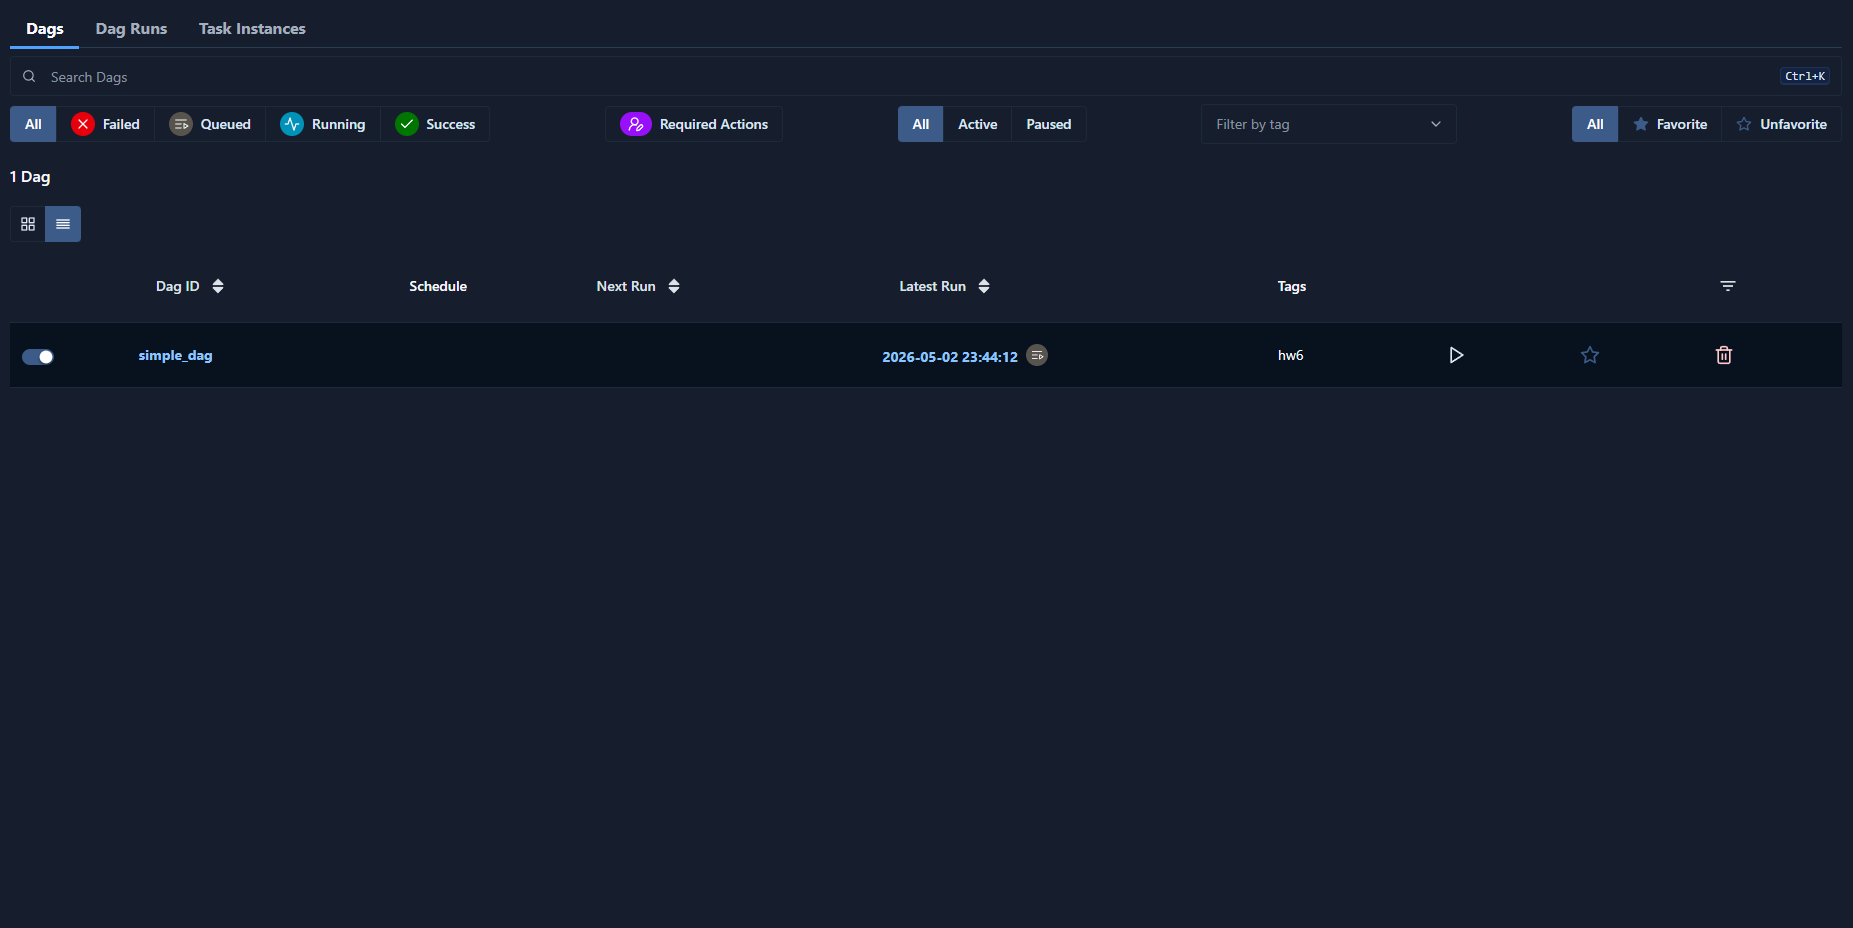

##10.3. Dag runs

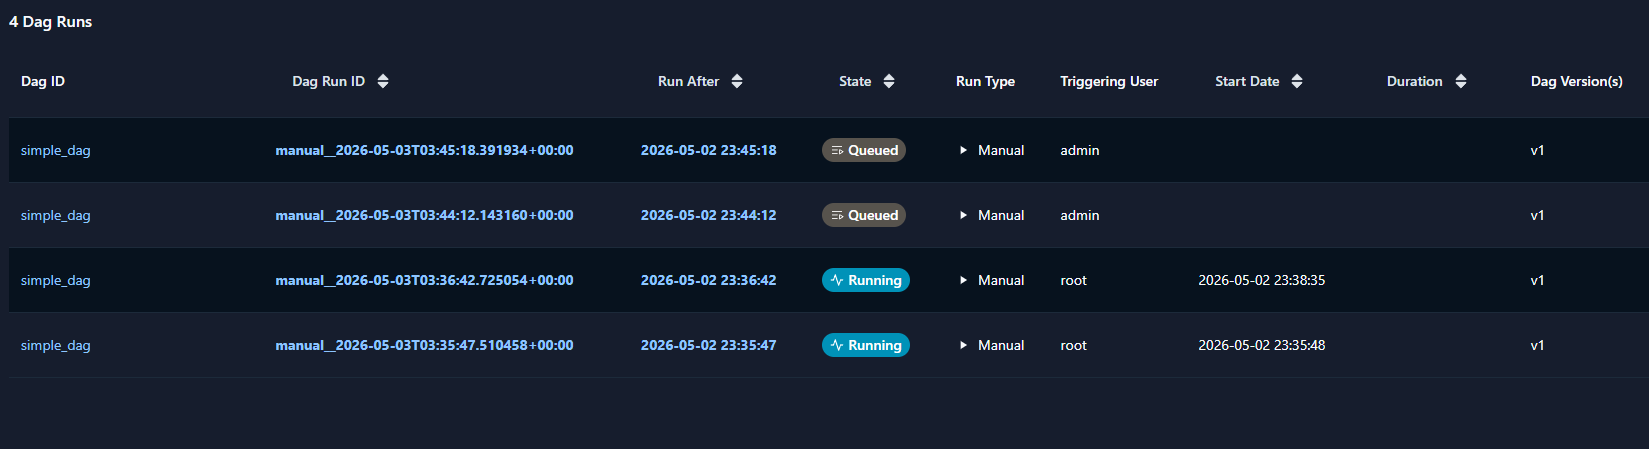

##10.4. Task Instances

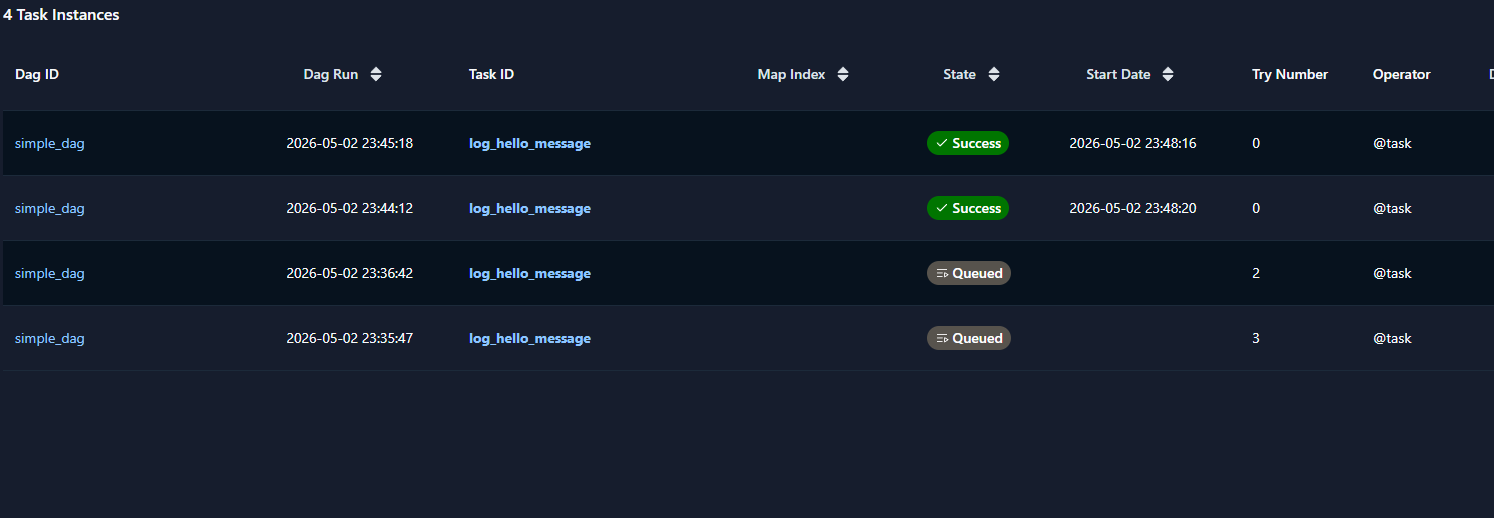